Exact solution: y(x) = y0 * exp(-2 sin(x))
lambda(x) = -2 cos(x)
Euler update: y_(n+1) = (1 - 2h cos(x_n)) y_n
Worst-case stability condition: |1 - 2h| < 1  ->  0 < h < 1

    h    max |1-2h cos(x_n)|    stable?
 0.05               1.099997        yes
 0.10               1.199994        yes
 0.15               1.299989        yes
 0.20               1.399984        yes
 0.25               1.499980        yes
 0.30               1.598343        yes
 0.35               1.699975        yes
 0.40               1.799969        yes
 0.45               1.899968        yes
 0.50               1.999961        yes
 0.55               2.099957        yes
 0.60               2.196686        yes
 0.65               2.292431        yes
 0.70               2.347648        yes
 0.75               2.498675        yes
 0.80               2.597272        yes
 0.85               2.695249        yes
 0.90               2.675353        yes
 0.95               2.894627        yes
 1.00               2.999922

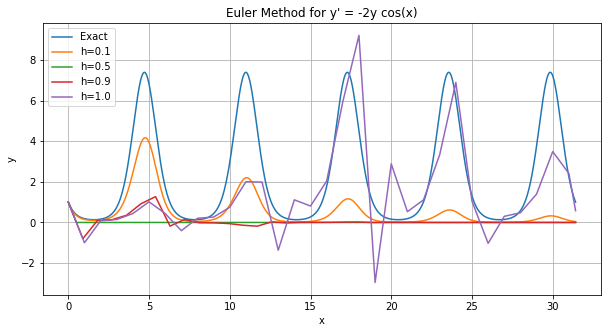

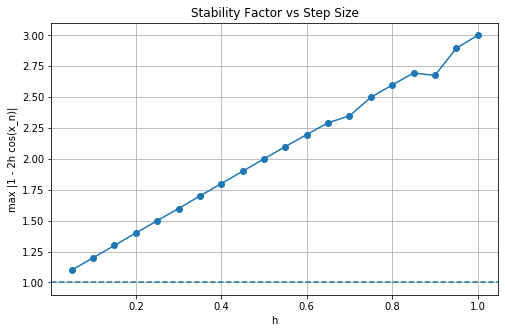

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def exact_solution(x, y0=1):
    return y0 * np.exp(-2 * np.sin(x))

def euler(x0, y0, x_end, h):
    xs = [x0]
    ys = [y0]
    amps = []
    x, y = x0, y0
    while x < x_end - 1e-12:
        step = min(h, x_end - x)
        a = 1 - 2 * step * np.cos(x)
        y = a * y
        x = x + step
        xs.append(x)
        ys.append(y)
        amps.append(abs(a))
    return np.array(xs), np.array(ys), np.array(amps)

x0 = 0
y0 = 1
x_end = 10 * np.pi

hs = np.arange(0.05, 1.05, 0.05)

print("Exact solution: y(x) = y0 * exp(-2 sin(x))")
print("lambda(x) = -2 cos(x)")
print("Euler update: y_(n+1) = (1 - 2h cos(x_n)) y_n")
print("Worst-case stability condition: |1 - 2h| < 1  ->  0 < h < 1\n")

print(f"{'h':>5} {'max |1-2h cos(x_n)|':>22} {'stable?':>10}")
for h in hs:
    xs, ys, amps = euler(x0, y0, x_end, h)
    max_amp = np.max(amps)
    stable = "yes" if h < 1 else "no"
    print(f"{h:5.2f} {max_amp:22.6f} {stable:>10}")

x_dense = np.linspace(x0, x_end, 3000)

plt.figure(figsize=(10, 5))
plt.plot(x_dense, exact_solution(x_dense, y0), label="Exact")
for h in [0.1, 0.5, 0.9, 1.0]:
    xs, ys, amps = euler(x0, y0, x_end, h)
    plt.plot(xs, ys, label=f"h={h}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler Method for y' = -2y cos(x)")
plt.legend()
plt.grid(True)
plt.show()

max_amps = []
for h in hs:
    xs, ys, amps = euler(x0, y0, x_end, h)
    max_amps.append(np.max(amps))

plt.figure(figsize=(8, 5))
plt.plot(hs, max_amps, "o-")
plt.axhline(1, linestyle="--")
plt.xlabel("h")
plt.ylabel("max |1 - 2h cos(x_n)|")
plt.title("Stability Factor vs Step Size")
plt.grid(True)
plt.show()

We can do a stability analysis, but it not a constant coefficient case. We apply the same idea of what we have done previously by treating it as y'=lambda(x)y. In this case, lambda depends on x. Since, the x value makes lambda change over the total interval